In [ ]:
!pip install git+https://github.com/ronnaug/chronocci

In [ ]:
import scanpy as sc
import chronocci as ch

adata = sc.datasets.pbmc3k_processed()

In [ ]:
# Let's rename the cluster column for compatibility
adata.obs["cell_type"] = adata.obs["louvain"].astype("category")

# Launching the pipeline
df_results = ch.run_joint_chronological_cci_pipeline(
    adata=adata,
    cluster_key="cell_type",
   # root_cell_type is an optional,
    species="human",
    top_n_per_lineage=10
)

LAUNCHING JOINT CHRONOLOGICAL CCI PIPELINE...
Automatically identified root: 'CD4 T cells'
INFO     Computing transition matrix based on pseudotime                                                           


  0%|          | 0/2638 [00:00<?, ?cell/s]

INFO         Finish (1.40s)                                                                                        
INFO     Computing transition matrix based on adata.obsp['connectivities']                                         
INFO         Finish (0.01s)                                                                                        
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                         

  0%|          | 0/3 [00:00<?, ?/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.20s)                                                                                        
Modeling temporal profiles for lineage: B cells...
Modeling temporal profiles for lineage: CD14+ Monocytes...
Modeling temporal profiles for lineage: CD8 T cells...


Analyzing paracrine interactions across cell types at trajectory peaks...
Integrative Streamgraph successfully saved to 'CCI_Streamgraph_Unified_Tissue_Cascade.pdf'!


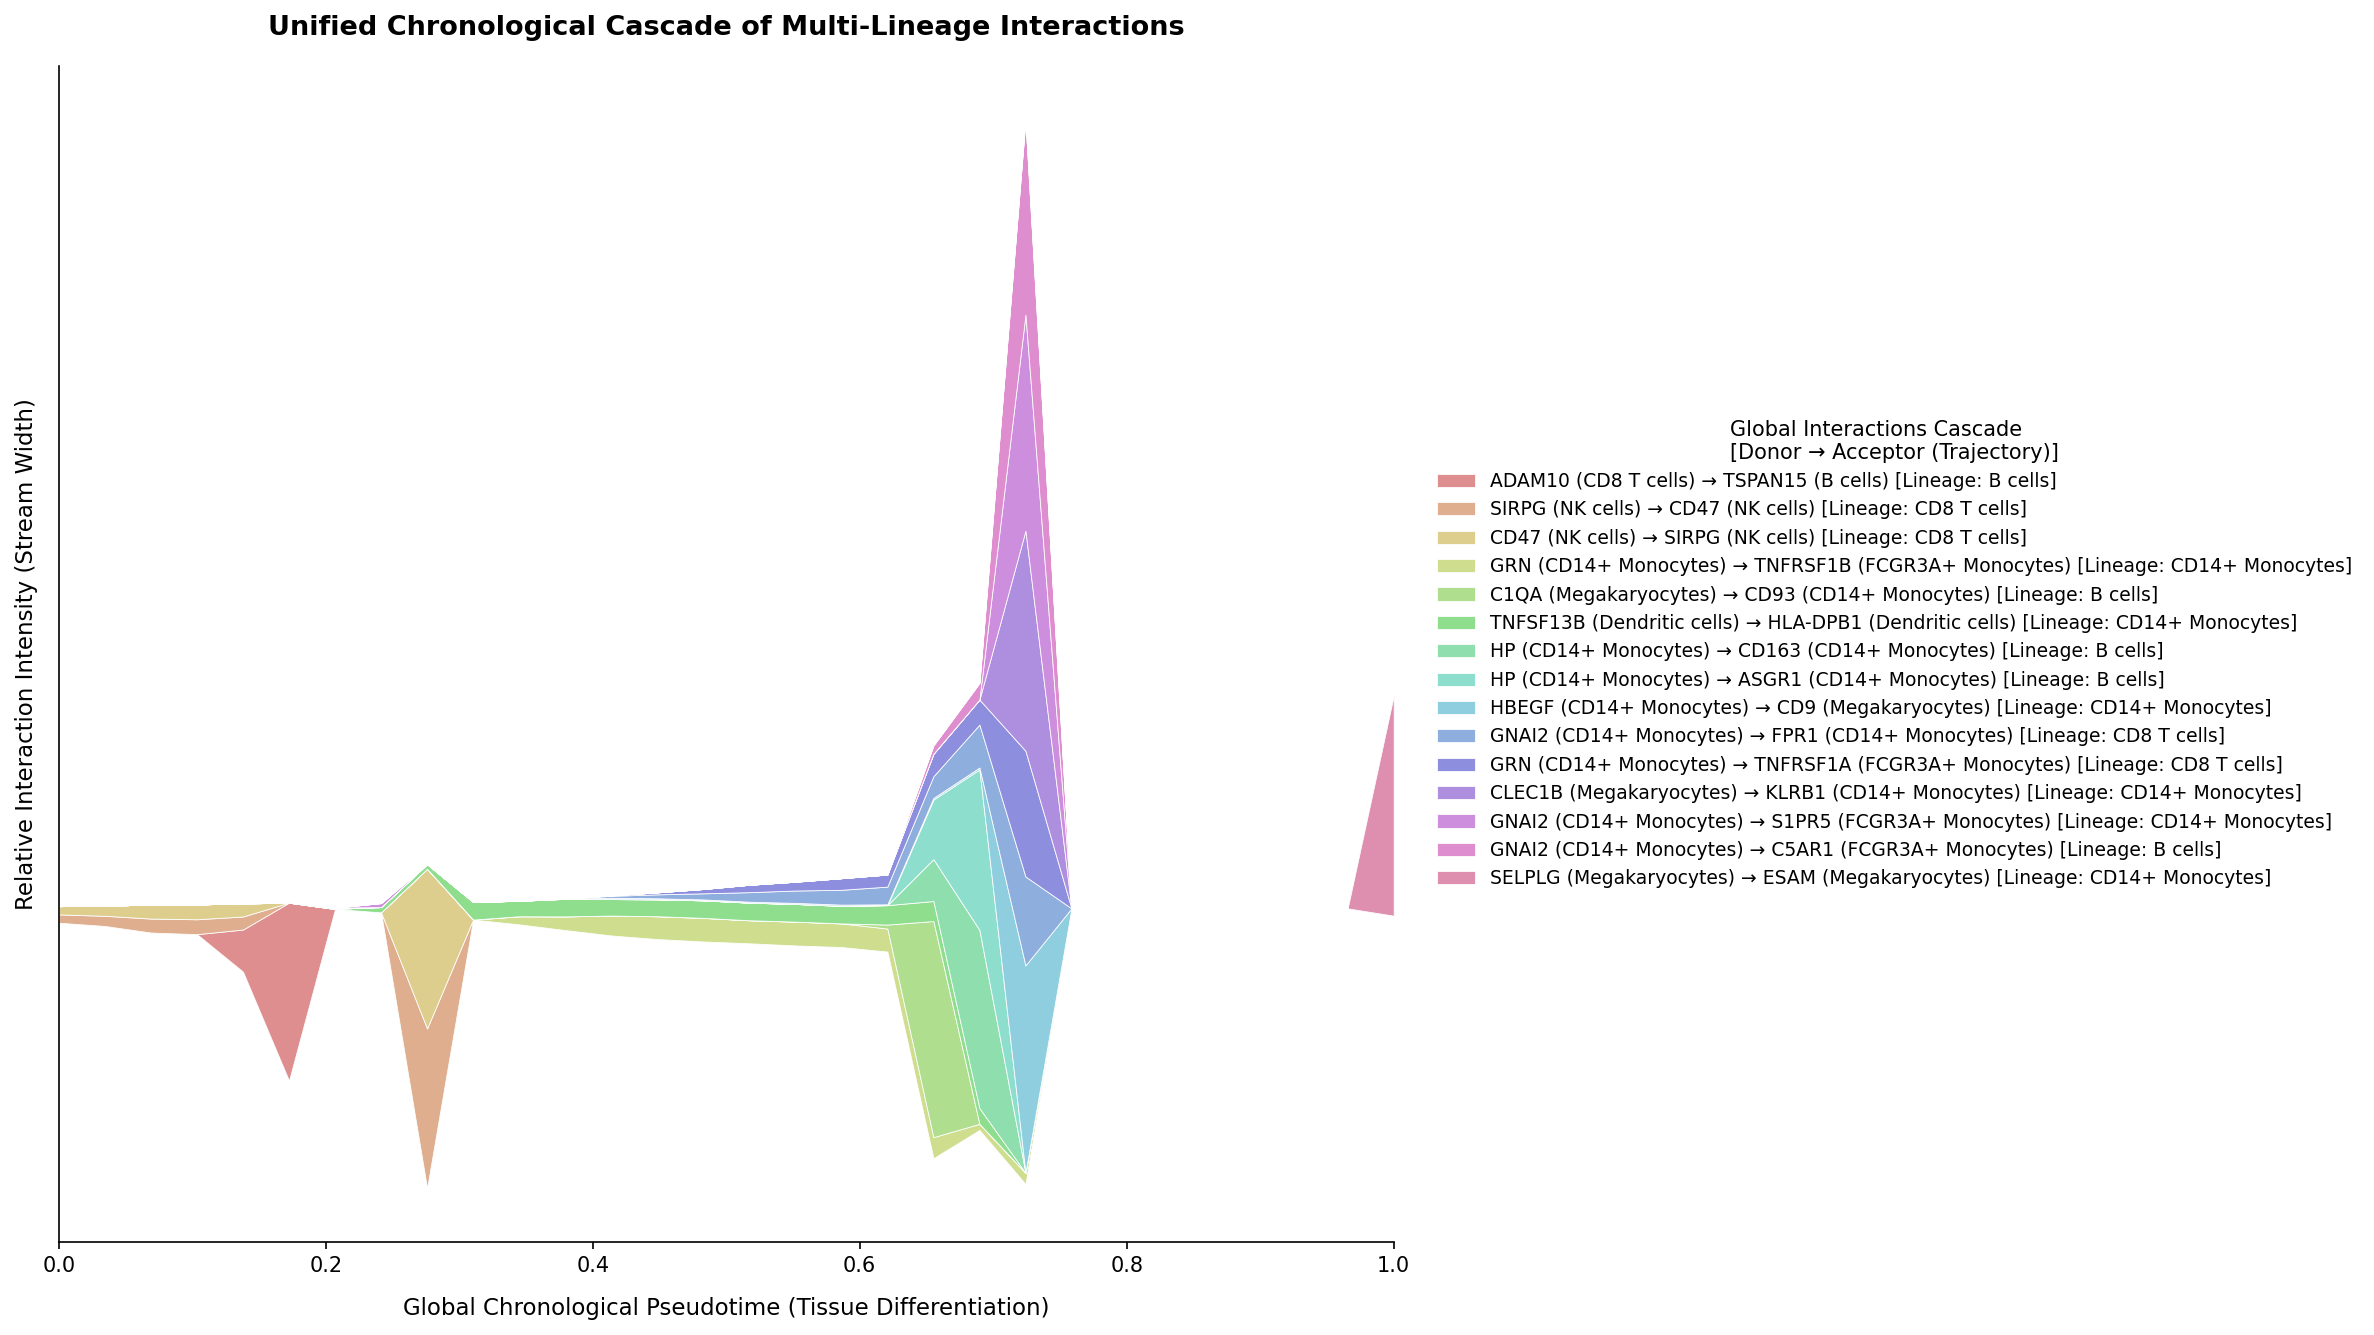

,interaction_pair,ligand,receptor,lineage,max_signal_raw,trajectory,peak_pseudotime,z_score_lineage,trajectory_norm
0,ADAM10_TSPAN15,ADAM10,TSPAN15,B cells,0.029156,"[0.0, 0.0, 0.0, 0.0, 0.006890130184164418, 0.0...",0.172414,-0.351077,"[0.0, 0.0, 0.0, 0.0, 5.73437501289433, 24.2656..."
1,SIRPG_CD47,SIRPG,CD47,CD8 T cells,0.108297,"[0.005614234460582107, 0.006902212956780618, 0...",0.275862,-0.315869,"[1.1286597926226263, 1.3875890469365062, 1.902..."
2,CD47_SIRPG,CD47,SIRPG,CD8 T cells,0.108297,"[0.005614234460582107, 0.006902212956780618, 0...",0.275862,-0.315869,"[1.1286597926226263, 1.3875890469365062, 1.902..."
3,GRN_TNFRSF1B,GRN,TNFRSF1B,CD14+ Monocytes,0.508246,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.000791951404112947...",0.551724,-0.003007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.00505725272206315,..."
4,C1QA_CD93,C1QA,CD93,B cells,0.030691,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.655172,-0.350155,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,TNFSF13B_HLA-DPB1,TNFSF13B,HLA-DPB1,CD14+ Monocytes,0.498810,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0056701691778...",0.655172,-0.011863,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0310346080055..."
6,HP_CD163,HP,CD163,B cells,0.107249,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.689655,-0.304180,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,HP_ASGR1,HP,ASGR1,B cells,0.187595,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.689655,-0.255931,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,HBEGF_CD9,HBEGF,CD9,CD14+ Monocytes,4.190440,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.009632421789727142...",0.724138,3.452462,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.06498850219405558,..."
9,GNAI2_FPR1,GNAI2,FPR1,CD8 T cells,1.755624,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,0.668794,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
import numpy as np
# Generate an integrative Streamgraph of unified multi-lineage interactions
# Define the same time grid vector used in our pipeline execution (e.g., 30 points)
time_grid = np.linspace(0, 1, 30)

ch.plot_signaling_streamgraph(
    adata=adata,
    df_final_sorted=df_results,
    cluster_key="cell_type",
    time_grid=time_grid,
    output_name="Unified_Tissue_Cascade"
)

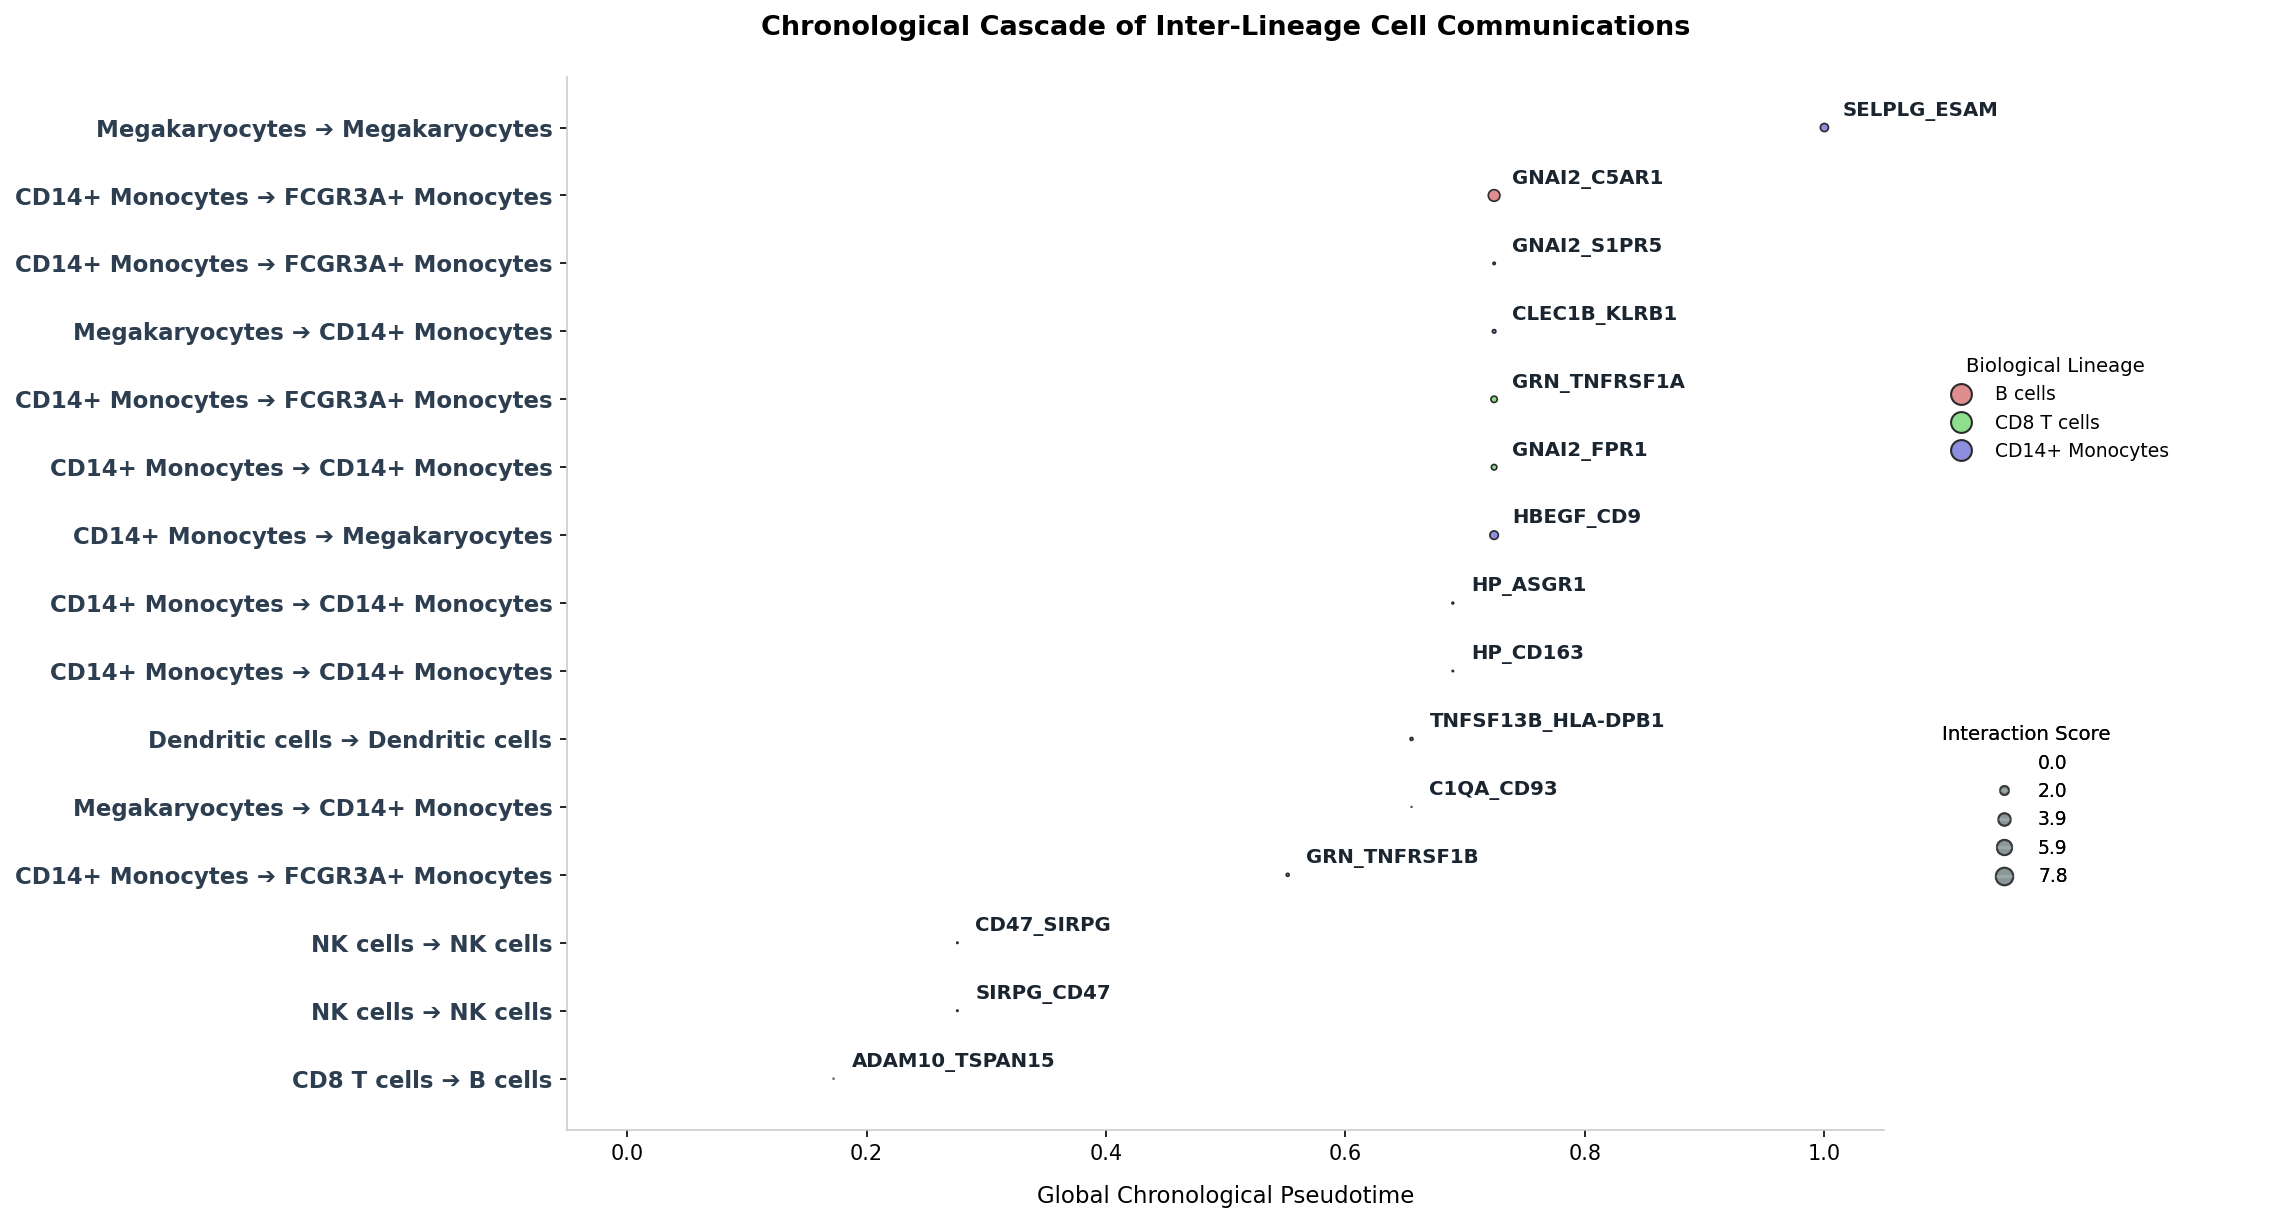

In [ ]:
ch.plot_cell_type_relay_timeline(
    adata=adata,
    df_final_sorted=df_results,
    cluster_key="cell_type",
    top_n=15,
    output_name="my_blood_study"
)

In [ ]:
df_results

,interaction_pair,ligand,receptor,lineage,max_signal_raw,trajectory,peak_pseudotime,z_score_lineage,trajectory_norm
0,ADAM10_TSPAN15,ADAM10,TSPAN15,B cells,0.029156,"[0.0, 0.0, 0.0, 0.0, 0.006890130184164418, 0.0...",0.172414,-0.351077,"[0.0, 0.0, 0.0, 0.0, 5.73437501289433, 24.2656..."
1,SIRPG_CD47,SIRPG,CD47,CD8 T cells,0.108297,"[0.005614234460582107, 0.006902212956780618, 0...",0.275862,-0.315869,"[1.1286597926226263, 1.3875890469365062, 1.902..."
2,CD47_SIRPG,CD47,SIRPG,CD8 T cells,0.108297,"[0.005614234460582107, 0.006902212956780618, 0...",0.275862,-0.315869,"[1.1286597926226263, 1.3875890469365062, 1.902..."
3,GRN_TNFRSF1B,GRN,TNFRSF1B,CD14+ Monocytes,0.508246,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.000791951404112947...",0.551724,-0.003007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.00505725272206315,..."
4,C1QA_CD93,C1QA,CD93,B cells,0.030691,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.655172,-0.350155,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,TNFSF13B_HLA-DPB1,TNFSF13B,HLA-DPB1,CD14+ Monocytes,0.498810,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0056701691778...",0.655172,-0.011863,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0310346080055..."
6,HP_CD163,HP,CD163,B cells,0.107249,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.689655,-0.304180,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,HP_ASGR1,HP,ASGR1,B cells,0.187595,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.689655,-0.255931,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,HBEGF_CD9,HBEGF,CD9,CD14+ Monocytes,4.190440,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.009632421789727142...",0.724138,3.452462,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.06498850219405558,..."
9,GNAI2_FPR1,GNAI2,FPR1,CD8 T cells,1.755624,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,0.668794,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
# 2. We find asymmetric switches between branches CD8 T cells and CD14+ Monocytes
df_asymmetric = ch.snoop_py(
    adata=adata,
    df_final_sorted=df_results,
    lineage_A="CD8 T cells",
    lineage_B="CD14+ Monocytes"
)

Screening for highly asymmetric CCI markers:
CD8 T cells vs CD14+ Monocytes...


In [ ]:
# Let's look at the first 10 asymmetric interactions found.
df_asymmetric.head(10)

,interaction_pair,ligand,receptor,lineage,max_signal_raw,trajectory,peak_pseudotime,z_score_lineage,trajectory_norm,bifurcation_score
0,ADAM10_TSPAN15,ADAM10,TSPAN15,B cells,0.029156,"[0.0, 0.0, 0.0, 0.0, 0.006890130184164418, 0.0...",0.172414,-0.351077,"[0.0, 0.0, 0.0, 0.0, 5.73437501289433, 24.2656...",0.072221
1,GNAI2_S1PR5,GNAI2,S1PR5,CD14+ Monocytes,0.318542,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00587141...",0.724138,-0.181032,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.54295735...",0.033511
2,CLEC1B_KLRB1,CLEC1B,KLRB1,CD14+ Monocytes,0.731977,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,0.206947,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.033333
3,SELPLG_ESAM,SELPLG,ESAM,CD14+ Monocytes,3.821912,"[0.0, 0.0, 0.0, 0.0, 0.0009257319322850191, 0....",1.000000,3.106625,"[0.0, 0.0, 0.0, 0.0, 0.007264749474791342, 0.0...",0.033333
4,GRN_TNFRSF1B,GRN,TNFRSF1B,CD14+ Monocytes,0.508246,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.000791951404112947...",0.551724,-0.003007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.00505725272206315,...",0.029126
5,GNAI2_C5AR1,GNAI2,C5AR1,B cells,7.799946,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,4.315433,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.026443
6,GRN_TNFRSF1A,GRN,TNFRSF1A,CD8 T cells,2.316134,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,1.003829,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.023486
7,GNAI2_FPR1,GNAI2,FPR1,CD8 T cells,1.755624,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.724138,0.668794,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.022102
8,C1QA_CD93,C1QA,CD93,B cells,0.030691,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.655172,-0.350155,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.013730
9,SIRPG_CD47,SIRPG,CD47,CD8 T cells,0.108297,"[0.005614234460582107, 0.006902212956780618, 0...",0.275862,-0.315869,"[1.1286597926226263, 1.3875890469365062, 1.902...",0.011926


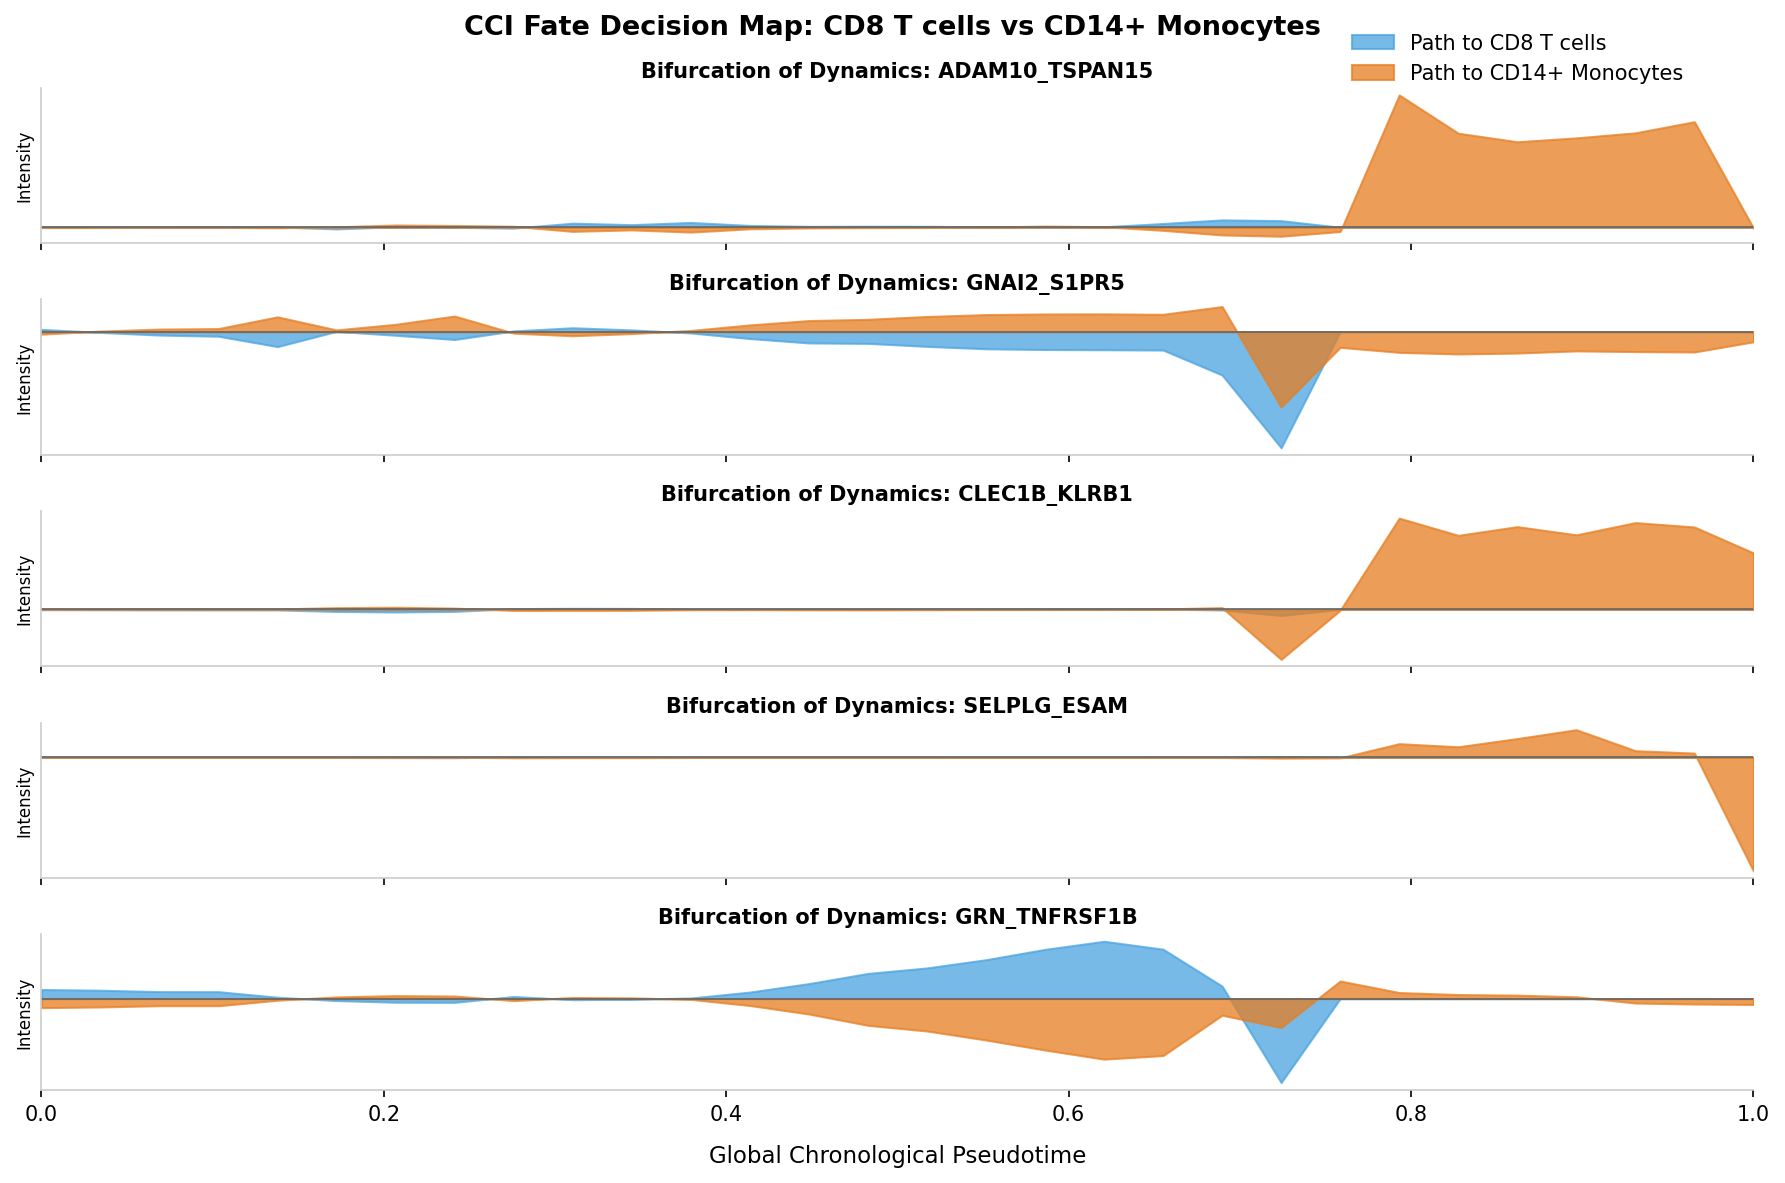

In [ ]:
# Now we start drawing the bifurcation graph
ch.plot_signaling_bifurcation(
    adata=adata,
    df_final_sorted=df_asymmetric,
    lineage_A="CD8 T cells",
    lineage_B="CD14+ Monocytes",
    top_n_pairs=5,
    output_name="my_blood_study"
)